In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Directory path
data_dir = os.path.dirname(os.path.abspath('analyzer.ipynb'))
if not data_dir:
    data_dir = '.'

In [2]:
# Load inaugural addresses
addresses = {}
for i in range(1, 6):
    file_path = os.path.join(data_dir, f'inauguralAddress{i}.txt')
    with open(file_path, 'r') as f:
        lines = f.readlines()
        president = lines[0].strip()
        year = lines[1].strip()
        text = ''.join(lines[2:]).strip()
        addresses[i] = {
            'president': president,
            'year': year,
            'text': text
        }

print("Loaded inaugural addresses:")
for i, addr in addresses.items():
    print(f"{i}. {addr['president']} ({addr['year']})")

Loaded inaugural addresses:
1. George W. Bush (January 20, 2001)
2. Harry S. Truman (January 20, 1949)
3. William McKinley (March 04, 1897)
4. James K. Polk (March 04, 1845)
5. George Washington (April 30, 1789)


In [3]:
# Perform sentiment analysis with Textblob and Vader
sentiment_results = {}

for i, addr in addresses.items():
    text = addr['text']
    
    # Textblob
    blob = TextBlob(text)
    textblob_sentiment = blob.sentiment.polarity  # Range: -1 to 1
    
    # Vader
    vader_scores = sia.polarity_scores(text)
    vader_sentiment = vader_scores['compound']  # Range: -1 to 1
    
    sentiment_results[i] = {
        'president': addr['president'],
        'year': addr['year'],
        'textblob': textblob_sentiment,
        'vader': vader_sentiment
    }
    
    print(f"{addr['president']} ({addr['year']}):")
    print(f"  TextBlob Sentiment: {textblob_sentiment:.4f}")
    print(f"  VADER Sentiment: {vader_sentiment:.4f}")
    print()


George W. Bush (January 20, 2001):
  TextBlob Sentiment: 0.1881
  VADER Sentiment: 0.9998

Harry S. Truman (January 20, 1949):
  TextBlob Sentiment: 0.1848
  VADER Sentiment: 1.0000

William McKinley (March 04, 1897):
  TextBlob Sentiment: 0.1883
  VADER Sentiment: 1.0000

James K. Polk (March 04, 1845):
  TextBlob Sentiment: 0.1571
  VADER Sentiment: 1.0000

George Washington (April 30, 1789):
  TextBlob Sentiment: 0.2065
  VADER Sentiment: 0.9999



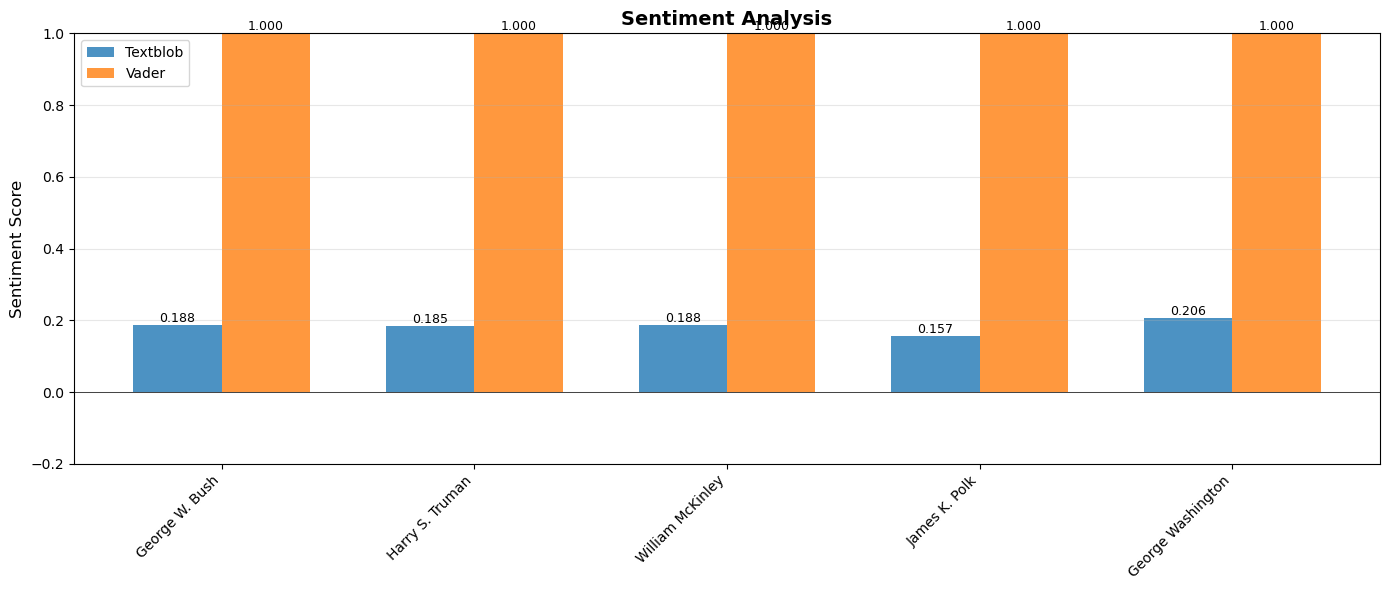

In [4]:
# Plot sentiment analysis results
presidents = [sentiment_results[i]['president'] for i in range(1, 6)]
textblob_scores = [sentiment_results[i]['textblob'] for i in range(1, 6)]
vader_scores = [sentiment_results[i]['vader'] for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(14, 6))

# Create x-axis positions
x = np.arange(len(presidents))
width = 0.35

# Plot bars
bars1 = ax.bar(x - width/2, textblob_scores, width, label='Textblob', alpha=0.8)
bars2 = ax.bar(x + width/2, vader_scores, width, label='Vader', alpha=0.8)

# Customize the plot
ax.set_ylabel('Sentiment Score', fontsize=12)
ax.set_title('Sentiment Analysis', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(presidents, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.2, 1.0)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Saved: wordcloud_George_W_Bush.png
Saved: wordcloud_Harry_S_Truman.png
Saved: wordcloud_William_McKinley.png
Saved: wordcloud_James_K_Polk.png
Saved: wordcloud_George_Washington.png


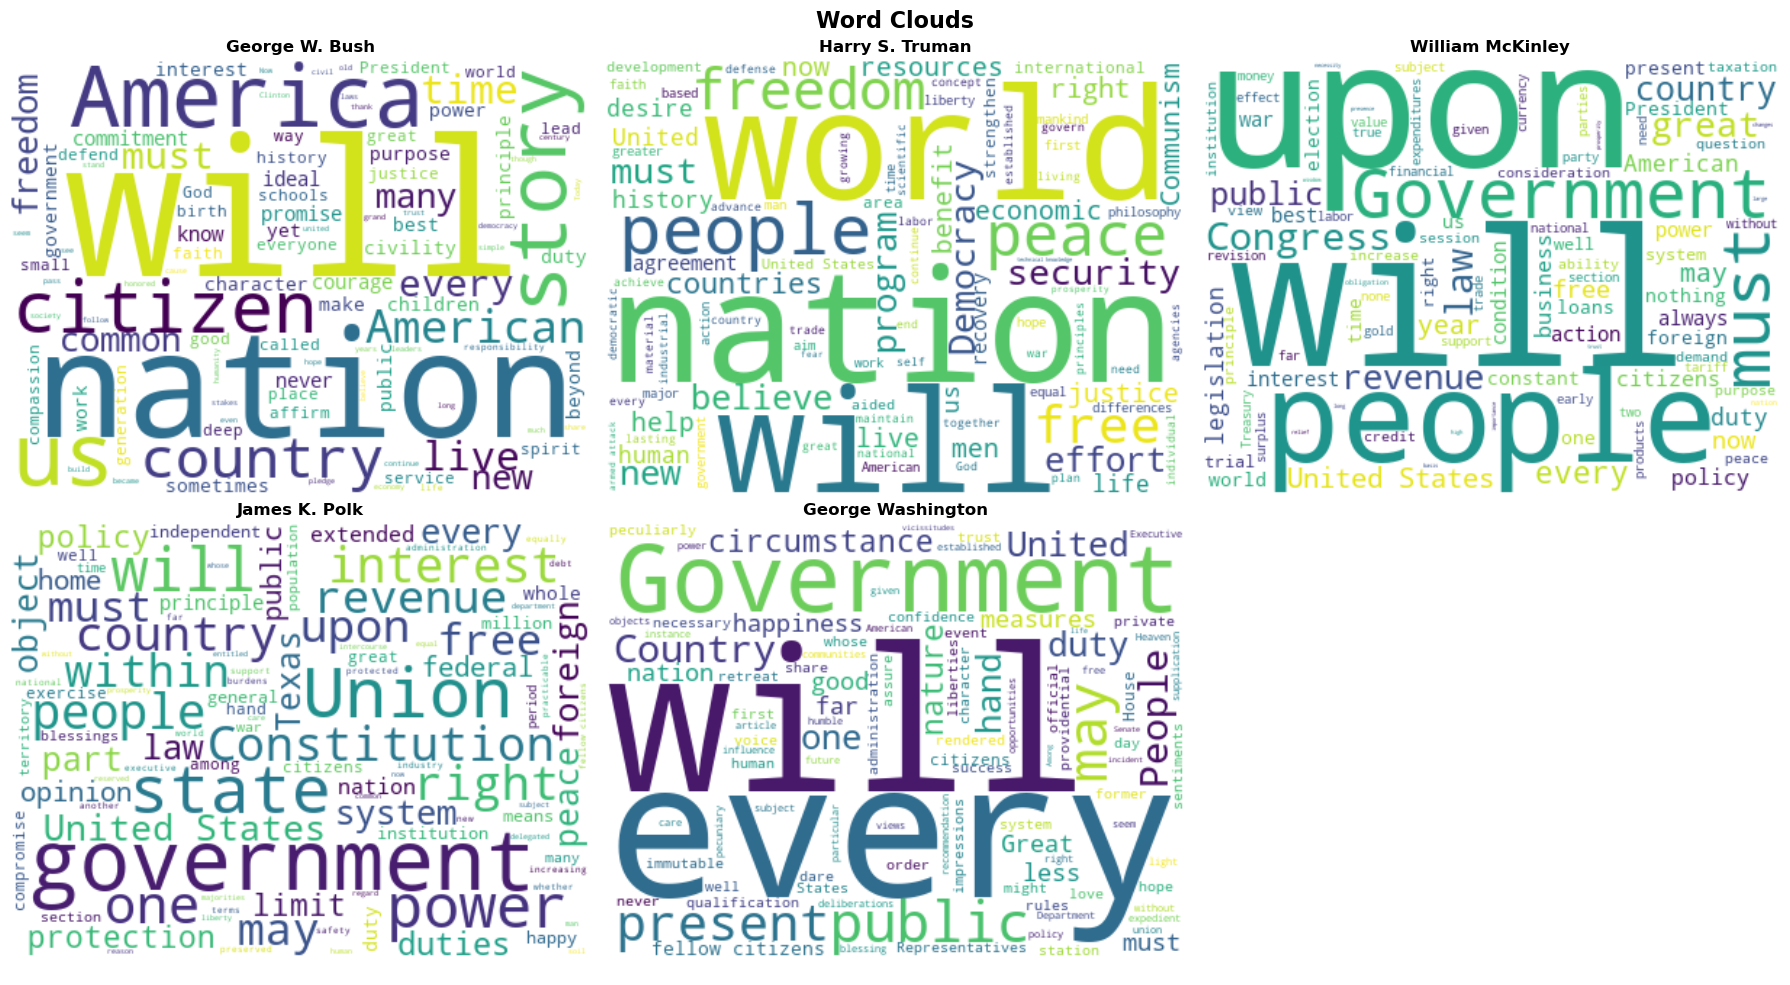

Word clouds saved


In [5]:
# Generate word clouds
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Word Clouds', fontsize=16, fontweight='bold')

# Flatten axes array
axes_flat = axes.flatten()

cloud_files = []
for i, addr in addresses.items():
    text = addr['text']
    president = addr['president']
    
    # Create word cloud
    wordcloud = WordCloud(width=400, height=300, background_color='white', max_words=100, colormap='viridis').generate(text)
    
    # Display in subplot
    ax = axes_flat[i-1]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"{president}", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Save as PNG
    filename = f"wordcloud_{president.replace(' ', '_').replace('.', '')}.png"
    filepath = os.path.join(data_dir, filename)
    wordcloud.to_file(filepath)
    cloud_files.append((president, filepath))
    print(f"Saved: {filename}")

# Hide the extra subplot
axes_flat[5].axis('off')

plt.tight_layout()
plt.show()

print('Word clouds saved')

In [6]:
# Compare sentiment methods and determine polarity agreement
def get_polarity_label(score):
    """Classify sentiment as Positive, Neutral, or Negative"""
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

comparison_results = []
agreement_count = 0

for i in range(1, 6):
    result = sentiment_results[i]
    president = result['president']
    textblob_score = result['textblob']
    vader_score = result['vader']
    
    textblob_polarity = get_polarity_label(textblob_score)
    vader_polarity = get_polarity_label(vader_score)
    
    agree = textblob_polarity == vader_polarity
    agreement_count += agree
    
    comparison_results.append({
        'president': president,
        'textblob_score': textblob_score,
        'vader_score': vader_score,
        'textblob_polarity': textblob_polarity,
        'vader_polarity': vader_polarity,
        'agree': agree
    })
    
    match_str = ""
    if agree:
        match_str = "Polarities match"
    else:
        match_str = "Polarities dont match"
    print(f"\n{president}:")
    print(f"Textblob: {textblob_score:7.4f} ({textblob_polarity})")
    print(f"Vader:    {vader_score:7.4f} ({vader_polarity})")
    print(f"  {match_str}")

# Summary statistics
agreement_percentage = (agreement_count / 5) * 100
print(f"Total polarity agreements: {agreement_count}/5 ({agreement_percentage:.1f}%)")
print(f"Total polarity disagreements: {5 - agreement_count}/5 ({100 - agreement_percentage:.1f}%)")

# Save results to output.txt
output_path = os.path.join(data_dir, 'output.txt')
with open(output_path, 'w') as f:
    
    for result in comparison_results:
        f.write(f"{result['president']}:\n")
        f.write(f"Textblob score: {result['textblob_score']:.4f} ({result['textblob_polarity']})\n")
        f.write(f"Vader score:    {result['vader_score']:.4f} ({result['vader_polarity']})\n")
        match_str = ""
        if agree:
            match_str = "Polarities match"
        else:
            match_str = "Polarities dont match"
        f.write(f"  Result: {match_str}\n\n")

    f.write(f"Polarity agreements: {agreement_count}/5 ({agreement_percentage:.1f}%)\n")
    
    f.write("Conclusion:\n")
    if agreement_percentage >= 80:
        f.write(f"Methods show strong agreement ({agreement_percentage:.1f}% match).\n")
    elif agreement_percentage >= 50:
        f.write(f"Methods show moderate agreement ({agreement_percentage:.1f}% match).\n")
    else:
        f.write(f"Methods show weak agreement ({agreement_percentage:.1f}% match).\n")

print(f"\nResults saved to output.txt")



George W. Bush:
Textblob:  0.1881 (Positive)
Vader:     0.9998 (Positive)
  Polarities match

Harry S. Truman:
Textblob:  0.1848 (Positive)
Vader:     1.0000 (Positive)
  Polarities match

William McKinley:
Textblob:  0.1883 (Positive)
Vader:     1.0000 (Positive)
  Polarities match

James K. Polk:
Textblob:  0.1571 (Positive)
Vader:     1.0000 (Positive)
  Polarities match

George Washington:
Textblob:  0.2065 (Positive)
Vader:     0.9999 (Positive)
  Polarities match
Total polarity agreements: 5/5 (100.0%)
Total polarity disagreements: 0/5 (0.0%)

Results saved to output.txt
